In [3]:
pip install duckdb


Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install panda_profiling

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement panda_profiling (from versions: none)
ERROR: No matching distribution found for panda_profiling


In [3]:
pip install fg-data-profiling

   ---------------------------------------- 0.0/400.3 kB ? eta -:--:--
   ---- ----------------------------------- 41.0/400.3 kB 1.9 MB/s eta 0:00:01
   ---- ----------------------------------- 41.0/400.3 kB 1.9 MB/s eta 0:00:01
   -------- ------------------------------ 92.2/400.3 kB 751.6 kB/s eta 0:00:01
   -------- ------------------------------ 92.2/400.3 kB 751.6 kB/s eta 0:00:01
   -------- ------------------------------ 92.2/400.3 kB 751.6 kB/s eta 0:00:01
   -------- ------------------------------ 92.2/400.3 kB 751.6 kB/s eta 0:00:01
   ------------------- ------------------ 204.8/400.3 kB 655.1 kB/s eta 0:00:01
   ------------------- ------------------ 204.8/400.3 kB 655.1 kB/s eta 0:00:01
   -------------------------- ----------- 276.5/400.3 kB 655.8 kB/s eta 0:00:01
   -------------------------- ----------- 276.5/400.3 kB 655.8 kB/s eta 0:00:01
   -------------------------------------  399.4/400.3 kB 754.1 kB/s eta 0:00:01
   -------------------------------------- 400.3/400

In [2]:
import duckdb
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!curl -LO https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data/transfermarkt-datasets.duckdb


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (35) schannel: next InitializeSecurityContext failed: CRYPT_E_NO_REVOCATION_CHECK (0x80092012) - The revocation function was unable to check revocation for the certificate.


In [3]:
print(os.path.getsize("transfermarkt-datasets.duckdb"))

211038208


In [4]:
con=duckdb.connect("transfermarkt-datasets.duckdb")
con.sql("SHOW TABLES").df()

,name
0,appearances
1,club_games
2,clubs
3,competitions
4,countries
5,game_events
6,game_lineups
7,games
8,national_teams
9,player_valuations


In [5]:
con.sql("DESCRIBE PLAYERS").df()

,column_name,column_type,null,key,default,extra
0,player_id,INTEGER,YES,None,None,None
1,first_name,VARCHAR,YES,None,None,None
2,last_name,VARCHAR,YES,None,None,None
3,name,VARCHAR,YES,None,None,None
4,last_season,VARCHAR,YES,None,None,None
5,current_club_id,VARCHAR,YES,None,None,None
6,player_code,VARCHAR,YES,None,None,None
7,country_of_birth,VARCHAR,YES,None,None,None
8,city_of_birth,VARCHAR,YES,None,None,None
9,country_of_citizenship,VARCHAR,YES,None,None,None


In [6]:
con.sql("DESCRIBE PLAYER_VALUATIONS").df()

,column_name,column_type,null,key,default,extra
0,player_id,INTEGER,YES,None,None,None
1,date,DATE,YES,None,None,None
2,market_value_in_eur,INTEGER,YES,None,None,None
3,current_club_name,VARCHAR,YES,None,None,None
4,current_club_id,INTEGER,YES,None,None,None
5,player_club_domestic_competition_id,VARCHAR,YES,None,None,None


In [7]:
con.sql("DESCRIBE CLUBS").df()

,column_name,column_type,null,key,default,extra
0,club_id,VARCHAR,YES,None,None,None
1,club_code,VARCHAR,YES,None,None,None
2,name,VARCHAR,YES,None,None,None
3,domestic_competition_id,VARCHAR,YES,None,None,None
4,total_market_value,FLOAT,YES,None,None,None
5,squad_size,INTEGER,YES,None,None,None
6,average_age,FLOAT,YES,None,None,None
7,foreigners_number,INTEGER,YES,None,None,None
8,foreigners_percentage,FLOAT,YES,None,None,None
9,national_team_players,INTEGER,YES,None,None,None


In [8]:
con.sql("DESCRIBE APPEARANCES").df()

,column_name,column_type,null,key,default,extra
0,appearance_id,VARCHAR,YES,None,None,None
1,game_id,INTEGER,YES,None,None,None
2,player_id,INTEGER,YES,None,None,None
3,player_club_id,INTEGER,YES,None,None,None
4,player_current_club_id,VARCHAR,YES,None,None,None
5,date,DATE,YES,None,None,None
6,player_name,VARCHAR,YES,None,None,None
7,competition_id,VARCHAR,YES,None,None,None
8,yellow_cards,INTEGER,YES,None,None,None
9,red_cards,INTEGER,YES,None,None,None


In [9]:
player_season_value=con.sql("""
    SELECT
        player_id,season,market_value,valuation_date
        FROM(
            SELECT 
                player_id,
                case
                    when extract(month from date)>=7 then extract(year from date)
                    else extract(year from date)-1
                end as season,
                market_value_in_eur as market_value,
                date as valuation_date,
                row_number() over (partition by player_id, 
                    case
                        when extract(month from date)>=7 then extract(year from date)
                        else extract(year from date)-1
                    end order by date desc)
                    as rn
            FROM player_valuations
            WHERE date>=current_date - interval '3 years'
            )
        WHERE rn=1
        """).df()

In [10]:
player_club_at_valuation = con.sql("""
    SELECT
        v.player_id,
        v.season,
        v.valuation_date,
        a.player_club_id
    FROM player_season_value v
    LEFT JOIN appearances a
        ON a.player_id = v.player_id
        AND a.date <= v.valuation_date
        AND a.date >= v.valuation_date - INTERVAL '1 year'
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY v.player_id, v.valuation_date
        ORDER BY a.date DESC
    ) = 1
""").df()

In [11]:
final = con.sql("""
    SELECT
        v.player_id, v.season,
        COUNT(a.date) AS appearances,
        CAST(COALESCE(SUM(a.goals), 0) AS INT) AS goals,
        CAST(COALESCE(SUM(a.assists), 0) AS INT) AS assists,
        CAST(COALESCE(SUM(a.minutes_played), 0) AS INT) AS minutes_played,
        v.market_value AS market_value_euro,
        p.name, p.position, p.sub_position,
        CAST(p.date_of_birth AS DATE) AS date_of_birth,
        DATEDIFF('year', CAST(p.date_of_birth AS DATE), v.valuation_date) AS age_at_valuation,
        p.contract_expiration_date, v.valuation_date,
        DATEDIFF('month', v.valuation_date, CAST(p.contract_expiration_date AS DATE)) AS months_remaining,
        cl.total_market_value AS club_total_market_value,
        cl.squad_size AS club_squad_size,
        comp.name AS competition_name
    FROM player_season_value v
    LEFT JOIN appearances a
        ON a.player_id = v.player_id
        AND a.date <= v.valuation_date
        AND a.date >= v.valuation_date - INTERVAL '1 year'
    JOIN players p
        ON p.player_id = v.player_id
    LEFT JOIN (
        SELECT
            v2.player_id, v2.valuation_date, a2.player_club_id
        FROM player_season_value v2
        LEFT JOIN appearances a2
            ON a2.player_id = v2.player_id
            AND a2.date <= v2.valuation_date
            AND a2.date >= v2.valuation_date - INTERVAL '1 year'
        QUALIFY ROW_NUMBER() OVER (
            PARTITION BY v2.player_id, v2.valuation_date
            ORDER BY a2.date DESC
        ) = 1
    ) pcv
        ON pcv.player_id = v.player_id AND pcv.valuation_date = v.valuation_date
    LEFT JOIN clubs cl
        ON cl.club_id = pcv.player_club_id
    LEFT JOIN competitions comp
        ON comp.competition_id = cl.domestic_competition_id
    GROUP BY
        v.player_id, v.season, v.market_value, p.name, p.position, p.sub_position,
        p.date_of_birth, p.contract_expiration_date, v.valuation_date,
        cl.total_market_value, cl.squad_size, comp.name
""").df()

In [12]:
final[final["name"]=="Phil Foden"]

,player_id,season,appearances,goals,assists,minutes_played,market_value_euro,name,position,sub_position,date_of_birth,age_at_valuation,contract_expiration_date,valuation_date,months_remaining,club_total_market_value,club_squad_size,competition_name
36713,406635,2023,56,27,12,4434,150000000,Phil Foden,Midfield,Attacking Midfield,2000-05-28,24,2027-06-30,2024-05-27,37,NaN,32,premier-league
40964,406635,2025,54,13,8,3196,70000000,Phil Foden,Midfield,Attacking Midfield,2000-05-28,26,2027-06-30,2026-06-03,12,NaN,32,premier-league
41420,406635,2024,43,10,6,2697,100000000,Phil Foden,Midfield,Attacking Midfield,2000-05-28,25,2027-06-30,2025-05-30,25,NaN,32,premier-league


In [13]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58970 entries, 0 to 58969
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   player_id                 58970 non-null  int32         
 1   season                    58970 non-null  int64         
 2   appearances               58970 non-null  int64         
 3   goals                     58970 non-null  int32         
 4   assists                   58970 non-null  int32         
 5   minutes_played            58970 non-null  int32         
 6   market_value_euro         58970 non-null  int32         
 7   name                      58970 non-null  object        
 8   position                  58970 non-null  object        
 9   sub_position              58919 non-null  object        
 10  date_of_birth             58967 non-null  datetime64[us]
 11  age_at_valuation          58967 non-null  Int64         
 12  contract_expiratio

In [14]:
final.head(10)

,player_id,season,appearances,goals,assists,minutes_played,market_value_euro,name,position,sub_position,date_of_birth,age_at_valuation,contract_expiration_date,valuation_date,months_remaining,club_total_market_value,club_squad_size,competition_name
0,246580,2023,7,0,0,438,350000,Fanos Katelaris,Defender,Centre-Back,1996-08-26,27,2025-05-31,2023-09-29,20,NaN,26,jupiler-pro-league
1,296340,2023,12,0,0,718,400000,Alfons Amade,Midfield,Defensive Midfield,1999-11-12,24,2024-06-30,2023-10-02,8,NaN,26,jupiler-pro-league
2,712560,2023,1,0,0,1,225000,Mikhail Sukhoruchenko,Defender,Centre-Back,2003-04-13,20,2024-06-30,2023-11-30,7,NaN,29,premier-liga
3,82105,2023,15,0,0,1150,8000000,Joel Matip,Defender,Centre-Back,1991-08-08,33,NaT,2024-05-27,<NA>,NaN,29,premier-league
4,402733,2023,23,0,3,1291,10000000,Gonzalo Montiel,Defender,Right-Back,1997-01-01,27,2028-12-31,2024-05-27,55,NaN,27,premier-league
5,230784,2023,17,0,0,973,18000000,Thomas Partey,Midfield,Defensive Midfield,1993-06-13,31,NaT,2024-05-27,<NA>,NaN,29,premier-league
6,983989,2023,37,4,1,1952,18000000,Facundo Buonanotte,Midfield,Attacking Midfield,2004-12-23,20,2028-06-30,2024-05-27,49,NaN,37,premier-league
7,238223,2023,45,0,0,3898,35000000,Ederson,Goalkeeper,Goalkeeper,1993-08-17,31,2028-06-30,2024-05-27,49,NaN,32,premier-league
8,344152,2023,34,8,0,1789,18000000,Odsonne Édouard,Attack,Centre-Forward,1998-01-16,26,2028-06-30,2024-05-27,49,NaN,31,premier-league
9,130164,2023,43,0,0,3870,22000000,Jordan Pickford,Goalkeeper,Goalkeeper,1994-03-07,30,2029-06-30,2024-05-27,61,NaN,23,premier-league


In [15]:
final["valuation_date"].isna().sum()

0

In [16]:
final["valuation_date"].dt.month.value_counts().sort_index()

valuation_date
1       220
2        90
3       343
4       391
5     17999
6     33932
7        10
8        20
9       365
10     1336
11     1413
12     2851
Name: count, dtype: int64

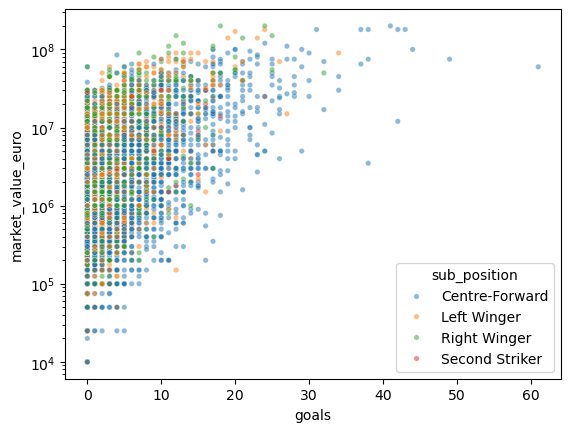

In [17]:
sns.scatterplot(x=final[final["position"]=="Attack"]["goals"],y=final["market_value_euro"],hue=final[final["position"]=="Attack"]["sub_position"],alpha=0.5,s=15)
plt.yscale("log")

In [18]:
final["months_remaining"].isna().sum()

10912

In [19]:
(final["months_remaining"]<0).sum()

990

In [20]:
final[final["appearances"].isnull()]

,player_id,season,appearances,goals,assists,minutes_played,market_value_euro,name,position,sub_position,date_of_birth,age_at_valuation,contract_expiration_date,valuation_date,months_remaining,club_total_market_value,club_squad_size,competition_name


In [21]:
zero_players=final[(final["appearances"]==0) & (final["season"]>2024)]
zero_players[["name","appearances","market_value_euro","season","valuation_date"]]

,name,appearances,market_value_euro,season,valuation_date
1444,Leonardo Flores,0,1000000,2025,2026-05-20
1447,Facundo Bruera,0,1800000,2025,2026-05-22
1448,Pablo Ferreira,0,350000,2025,2026-05-22
1450,Golib Gaybullaev,0,450000,2025,2026-05-13
1453,Jhon Gamboa,0,400000,2025,2026-05-12
...,...,...,...,...,...
58952,Omar Janneh,0,4000000,2025,2026-06-02
58956,Ahmed Hassan,0,600000,2025,2026-06-04
58959,Marcin Kamiński,0,250000,2025,2026-06-04
58965,Rodrigo Echeverría,0,2500000,2025,2026-05-20


In [22]:
zero_players['position'].value_counts()

position
Defender      3379
Midfield      2906
Attack        2672
Goalkeeper    1326
Missing         27
Name: count, dtype: int64

In [23]:
sample_row = zero_players.iloc[1]
pid = sample_row['player_id']
vdate = sample_row['valuation_date']
print(pid, vdate)

con.sql(f"""
    SELECT date FROM appearances
    WHERE player_id = {pid}
    ORDER BY date
""").df()

538880 2026-05-22 00:00:00


,date


In [24]:
zero_players.iloc[0]

player_id                               1011115
season                                     2025
appearances                                   0
goals                                         0
assists                                       0
minutes_played                                0
market_value_euro                       1000000
name                            Leonardo Flores
position                                 Attack
sub_position                     Centre-Forward
date_of_birth               2003-04-21 00:00:00
age_at_valuation                             23
contract_expiration_date                    NaT
valuation_date              2026-05-20 00:00:00
months_remaining                           <NA>
club_total_market_value                     NaN
club_squad_size                            <NA>
competition_name                           None
Name: 1444, dtype: object

In [25]:
final['has_contract_date'] = final['contract_expiration_date'].notna().astype(int)

final

,player_id,season,appearances,goals,assists,minutes_played,market_value_euro,name,position,sub_position,date_of_birth,age_at_valuation,contract_expiration_date,valuation_date,months_remaining,club_total_market_value,club_squad_size,competition_name,has_contract_date
0,246580,2023,7,0,0,438,350000,Fanos Katelaris,Defender,Centre-Back,1996-08-26,27,2025-05-31,2023-09-29,20,NaN,26,jupiler-pro-league,1
1,296340,2023,12,0,0,718,400000,Alfons Amade,Midfield,Defensive Midfield,1999-11-12,24,2024-06-30,2023-10-02,8,NaN,26,jupiler-pro-league,1
2,712560,2023,1,0,0,1,225000,Mikhail Sukhoruchenko,Defender,Centre-Back,2003-04-13,20,2024-06-30,2023-11-30,7,NaN,29,premier-liga,1
3,82105,2023,15,0,0,1150,8000000,Joel Matip,Defender,Centre-Back,1991-08-08,33,NaT,2024-05-27,<NA>,NaN,29,premier-league,0
4,402733,2023,23,0,3,1291,10000000,Gonzalo Montiel,Defender,Right-Back,1997-01-01,27,2028-12-31,2024-05-27,55,NaN,27,premier-league,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58965,265726,2025,0,0,0,0,2500000,Rodrigo Echeverría,Midfield,Defensive Midfield,1995-04-07,31,2027-12-31,2026-05-20,19,NaN,<NA>,None,1
58966,279657,2023,0,0,0,0,50000,Nico Rinderknecht,Midfield,Defensive Midfield,1997-10-11,26,2024-06-30,2023-09-12,9,NaN,<NA>,None,1
58967,546033,2023,0,0,0,0,1000000,Sabino,Defender,Centre-Back,1996-10-25,28,2028-12-31,2024-06-17,54,NaN,<NA>,None,1
58968,609453,2025,0,0,0,0,150000,Kevin Carabantes,Goalkeeper,Goalkeeper,1995-03-20,31,2028-06-30,2026-06-01,24,NaN,<NA>,None,1


In [26]:
final=final[(final["months_remaining"].isna())|(final["months_remaining"]>=0)].copy()
final.shape[0]

57980

In [27]:
final["months_remaining"].isna().sum() 

10912

In [28]:
final = final.sort_values(['player_id', 'season']).reset_index(drop=True)

final['prev_market_value'] = final.groupby('player_id')['market_value_euro'].shift(1)
final['prev_value_log'] = np.log1p(final['prev_market_value'])
final['has_prev_value'] = final['prev_value_log'].notna().astype(int)

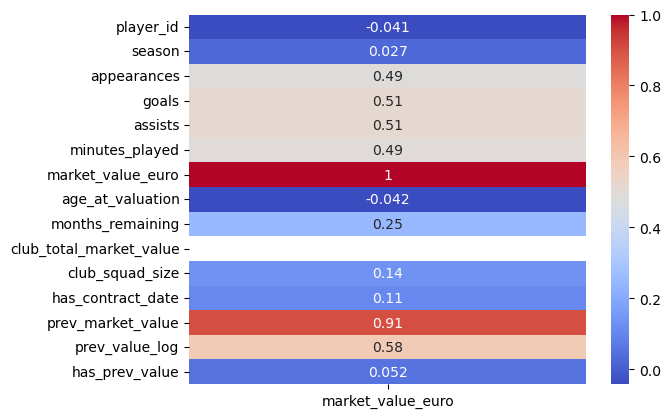

In [29]:
sns.heatmap(final.corr(numeric_only=True)[["market_value_euro"]],annot=True,cmap="coolwarm")
plt.show()

<Axes: xlabel='age_at_valuation', ylabel='market_value_euro'>

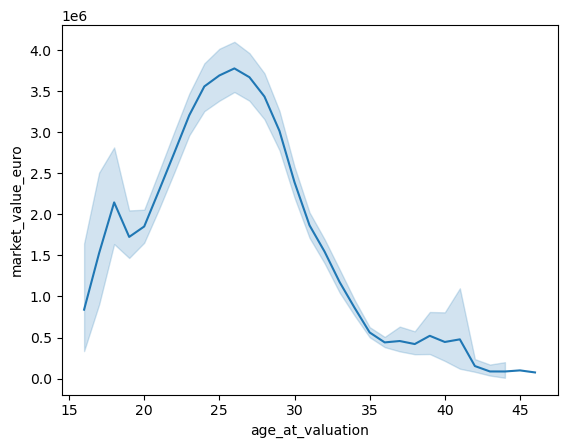

In [30]:
sns.lineplot(x=final["age_at_valuation"],y=final["market_value_euro"])

In [31]:
(final["appearances"]==0).sum()

34738

In [32]:
final[final["appearances"]==0]['season'].value_counts().sort_index()

season
2023    13452
2024    11209
2025    10077
Name: count, dtype: int64

In [33]:
final["recently_active"]=(final["appearances"]>0).astype(int)

In [34]:
final["goals_by_90"]=final["goals"]/final["minutes_played"]*90
final["assists_by_90"]=final["assists"]/final["minutes_played"]*90

In [35]:
final["goals_by_90"].isna().sum()

34738

In [36]:
final["assists_by_90"].isna().sum()

34738

In [37]:
#checks how many rows have matching null-statusfina
#(final["assists_scaled_by_position"].isna()==final["goals_scaled_by_position"].isna()).sum() ---> 1==1,0==0 it is correct -->so it gives count of all boolean matching values

(final["assists_by_90"].isna()!=final["goals_by_90"].isna()).sum()

0

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
#don't perform stratify unless it is for bins
#row wise splitting ---> leads to data leakage , highly inflated values coming twice or more affects the overall value
#so we use player_id wise splitting while keeping it unique to avoid any data leakage
#will contain only id

train,test=train_test_split(
    final["player_id"].unique(),test_size=0.2,random_state=42)

In [40]:
final["months_remaining_missing"]=final["months_remaining"].notna().astype(int)

In [41]:
final.columns

Index(['player_id', 'season', 'appearances', 'goals', 'assists',
       'minutes_played', 'market_value_euro', 'name', 'position',
       'sub_position', 'date_of_birth', 'age_at_valuation',
       'contract_expiration_date', 'valuation_date', 'months_remaining',
       'club_total_market_value', 'club_squad_size', 'competition_name',
       'has_contract_date', 'prev_market_value', 'prev_value_log',
       'has_prev_value', 'recently_active', 'goals_by_90', 'assists_by_90',
       'months_remaining_missing'],
      dtype='object')

In [42]:
features=['season','appearances','minutes_played','position','months_remaining', 'age_at_valuation', 'goals_by_90_scaled_by_position','assists_by_90_scaled_by_position','club_squad_size','has_contract_date','months_remaining_missing','competition_name','prev_value_log','has_prev_value']

In [43]:
train_players=final[final["player_id"].isin(train)]
test_players=final[final["player_id"].isin(test)]

In [44]:
imp=["goals_by_90","assists_by_90"]
nuetral=["appearances","minutes_played"]

position_stats=train_players.groupby("position").agg(
    goals_by_90_mean=("goals_by_90","mean"),
    assists_by_90_mean=("assists_by_90","mean"),
    goals_by_90_std=("goals_by_90","std"),
    assists_by_90_std=("assists_by_90","std")
)
position_stats

,goals_by_90_mean,assists_by_90_mean,goals_by_90_std,assists_by_90_std
position,,,,
Attack,0.299228,0.165851,1.525273,1.256120
Defender,0.043681,0.059096,0.137702,0.146379
Goalkeeper,0.000180,0.004124,0.003177,0.033133
Midfield,0.111097,0.108705,0.318660,0.250309
Missing,0.000000,0.000000,0.000000,0.000000


In [45]:
def scale(df,stats):
    df=df.copy()

    g_mean=df["position"].map(stats["goals_by_90_mean"])
    g_std=df["position"].map(stats["goals_by_90_std"])
    a_mean=df["position"].map(stats["assists_by_90_mean"])
    a_std=df["position"].map(stats["assists_by_90_std"])

    df["goals_by_90_scaled_by_position"]=(df["goals_by_90"]-g_mean)/g_std
    df["assists_by_90_scaled_by_position"]=(df["assists_by_90"]-a_mean)/a_std

    return df

train_players=scale(train_players,position_stats)
test_players=scale(test_players,position_stats)

In [46]:
train_players.head()

,player_id,season,appearances,goals,assists,minutes_played,market_value_euro,name,position,sub_position,...,has_contract_date,prev_market_value,prev_value_log,has_prev_value,recently_active,goals_by_90,assists_by_90,months_remaining_missing,goals_by_90_scaled_by_position,assists_by_90_scaled_by_position
0,2989,2023,0,0,0,0,100000,Paolo Guerrero,Attack,Centre-Forward,...,1,NaN,NaN,0,0,NaN,NaN,1,NaN,NaN
1,2989,2024,0,0,0,0,50000,Paolo Guerrero,Attack,Centre-Forward,...,1,100000.0,11.512935,1,0,NaN,NaN,1,NaN,NaN
2,2989,2025,0,0,0,0,50000,Paolo Guerrero,Attack,Centre-Forward,...,1,50000.0,10.819798,1,0,NaN,NaN,1,NaN,NaN
3,3333,2023,21,0,2,1045,1000000,James Milner,Midfield,Central Midfield,...,0,NaN,NaN,0,1,0.0,0.172249,0,-0.348637,0.253861
4,3333,2024,4,0,0,173,1000000,James Milner,Midfield,Central Midfield,...,0,1000000.0,13.815512,1,1,0.0,0.000000,0,-0.348637,-0.434285


In [47]:
X_train=train_players[features].copy()

In [48]:
X_test=test_players[features].copy()

In [49]:
y_train=np.log1p(train_players["market_value_euro"])
y_test=np.log1p(test_players["market_value_euro"])

In [50]:
X_train.head()

,season,appearances,minutes_played,position,months_remaining,age_at_valuation,goals_by_90_scaled_by_position,assists_by_90_scaled_by_position,club_squad_size,has_contract_date,months_remaining_missing,competition_name,prev_value_log,has_prev_value
0,2023,0,0,Attack,31,40,NaN,NaN,<NA>,1,1,None,NaN,0
1,2024,0,0,Attack,18,41,NaN,NaN,<NA>,1,1,None,11.512935,1
2,2025,0,0,Attack,6,42,NaN,NaN,<NA>,1,1,None,10.819798,1
3,2023,21,1045,Midfield,<NA>,38,-0.348637,0.253861,37,0,0,premier-league,NaN,0
4,2024,4,173,Midfield,<NA>,39,-0.348637,-0.434285,37,0,0,premier-league,13.815512,1


In [51]:
X_train.shape[0]

46423

In [52]:
X_test.shape[0]

11557

In [53]:
X_train = pd.get_dummies(X_train, columns=["position", "competition_name"])
X_test = pd.get_dummies(X_test, columns=["position", "competition_name"])


In [54]:
X_test.head()

,season,appearances,minutes_played,months_remaining,age_at_valuation,goals_by_90_scaled_by_position,assists_by_90_scaled_by_position,club_squad_size,has_contract_date,months_remaining_missing,...,competition_name_saudi-pro-league,competition_name_scottish-premiership,competition_name_serie-a,competition_name_super-league,competition_name_super-league-1,competition_name_super-lig,competition_name_super-liga-srbije,competition_name_superliga,competition_name_supersport-hnl,competition_name_torneo-apertura
36,2023,0,0,30,36,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
37,2024,0,0,18,37,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
38,2025,0,0,7,38,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
59,2023,0,0,<NA>,39,NaN,NaN,<NA>,0,0,...,False,False,False,False,False,False,False,False,False,False
60,2024,0,0,<NA>,40,NaN,NaN,<NA>,0,0,...,False,False,False,False,False,False,False,False,False,False


In [55]:
X_train.head()

,season,appearances,minutes_played,months_remaining,age_at_valuation,goals_by_90_scaled_by_position,assists_by_90_scaled_by_position,club_squad_size,has_contract_date,months_remaining_missing,...,competition_name_saudi-pro-league,competition_name_scottish-premiership,competition_name_serie-a,competition_name_super-league,competition_name_super-league-1,competition_name_super-lig,competition_name_super-liga-srbije,competition_name_superliga,competition_name_supersport-hnl,competition_name_torneo-apertura
0,2023,0,0,31,40,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
1,2024,0,0,18,41,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
2,2025,0,0,6,42,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
3,2023,21,1045,<NA>,38,-0.348637,0.253861,37,0,0,...,False,False,False,False,False,False,False,False,False,False
4,2024,4,173,<NA>,39,-0.348637,-0.434285,37,0,0,...,False,False,False,False,False,False,False,False,False,False


In [56]:
X_test=X_test.reindex(columns=X_train.columns,fill_value=0)

In [57]:
X_test.head()

,season,appearances,minutes_played,months_remaining,age_at_valuation,goals_by_90_scaled_by_position,assists_by_90_scaled_by_position,club_squad_size,has_contract_date,months_remaining_missing,...,competition_name_saudi-pro-league,competition_name_scottish-premiership,competition_name_serie-a,competition_name_super-league,competition_name_super-league-1,competition_name_super-lig,competition_name_super-liga-srbije,competition_name_superliga,competition_name_supersport-hnl,competition_name_torneo-apertura
36,2023,0,0,30,36,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
37,2024,0,0,18,37,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
38,2025,0,0,7,38,NaN,NaN,<NA>,1,1,...,False,False,False,False,False,False,False,False,False,False
59,2023,0,0,<NA>,39,NaN,NaN,<NA>,0,0,...,False,False,False,False,False,False,False,False,False,False
60,2024,0,0,<NA>,40,NaN,NaN,<NA>,0,0,...,False,False,False,False,False,False,False,False,False,False


In [58]:
X_test.columns

Index(['season', 'appearances', 'minutes_played', 'months_remaining',
       'age_at_valuation', 'goals_by_90_scaled_by_position',
       'assists_by_90_scaled_by_position', 'club_squad_size',
       'has_contract_date', 'months_remaining_missing', 'prev_value_log',
       'has_prev_value', 'position_Attack', 'position_Defender',
       'position_Goalkeeper', 'position_Midfield', 'position_Missing',
       'competition_name_allsvenskan', 'competition_name_bundesliga',
       'competition_name_campeonato-brasileiro-serie-a',
       'competition_name_chance-liga', 'competition_name_eliteserien',
       'competition_name_eredivisie', 'competition_name_j1-league',
       'competition_name_jupiler-pro-league', 'competition_name_k-league-1',
       'competition_name_laliga', 'competition_name_liga-mx-clausura',
       'competition_name_liga-portugal', 'competition_name_ligue-1',
       'competition_name_major-league-soccer',
       'competition_name_pko-bp-ekstraklasa',
       'competition_n

In [59]:
X_test["months_remaining"].isna().sum()

2258

In [60]:
X_train["months_remaining"].isna().sum()

8654

In [61]:
import xgboost as xgb

In [62]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [63]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

param_dist = {
    'max_depth': [4, 6, 8, 10],
    'n_estimators': [300, 600, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5]
}

gkf = GroupKFold(n_splits=5)
groups = train_players['player_id']

search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=list(gkf.split(X_train, y_train, groups=groups)),
    scoring='r2',
    random_state=42,
    verbose=1,
    n_jobs=-1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

model = search.best_estimator_  # replaces your old `model = xgb.XGBRegressor(...); model.fit(...)`

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.85, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV R²: 0.7742845509700604


In [64]:
y_train_pred=model.predict(X_train)


In [65]:
y_test_pred=model.predict(X_test)

In [66]:
mse_train=mean_squared_error(y_train,y_train_pred)
mea_train=mean_absolute_error(y_train,y_train_pred)
r2_train=r2_score(y_train,y_train_pred)

In [67]:
mse_test=mean_squared_error(y_test,y_test_pred)
mea_test=mean_absolute_error(y_test,y_test_pred)
r2_test=r2_score(y_test,y_test_pred)

In [68]:
print(mse_train)
print(mea_train)
print(r2_train)

0.4693414078746413
0.47184928684428246
0.8042955308828914


In [69]:
print(mse_test)
print(mea_test)
print(r2_test)

0.539531109114441
0.5154246834799273
0.7786337189272384


In [70]:
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance)

prev_value_log                                    0.197484
competition_name_premier-league                   0.120860
appearances                                       0.115929
competition_name_bundesliga                       0.049399
competition_name_ligue-1                          0.041486
competition_name_serie-a                          0.040300
has_contract_date                                 0.036614
has_prev_value                                    0.033092
minutes_played                                    0.033066
competition_name_scottish-premiership             0.031553
position_Goalkeeper                               0.031466
months_remaining                                  0.030558
competition_name_laliga                           0.028115
competition_name_premier-liga                     0.027770
age_at_valuation                                  0.023900
competition_name_super-league-1                   0.017411
competition_name_superliga                        0.0142

In [71]:
X_train.columns

Index(['season', 'appearances', 'minutes_played', 'months_remaining',
       'age_at_valuation', 'goals_by_90_scaled_by_position',
       'assists_by_90_scaled_by_position', 'club_squad_size',
       'has_contract_date', 'months_remaining_missing', 'prev_value_log',
       'has_prev_value', 'position_Attack', 'position_Defender',
       'position_Goalkeeper', 'position_Midfield', 'position_Missing',
       'competition_name_allsvenskan', 'competition_name_bundesliga',
       'competition_name_campeonato-brasileiro-serie-a',
       'competition_name_chance-liga', 'competition_name_eliteserien',
       'competition_name_eredivisie', 'competition_name_j1-league',
       'competition_name_jupiler-pro-league', 'competition_name_k-league-1',
       'competition_name_laliga', 'competition_name_liga-mx-clausura',
       'competition_name_liga-portugal', 'competition_name_ligue-1',
       'competition_name_major-league-soccer',
       'competition_name_pko-bp-ekstraklasa',
       'competition_n

In [72]:
def value(appearances,minutes_played,months_remaining,age_at_valuation,goals,assists,club_squad_size,position,prev_market_value,competition_name):

    goals_by90=goals/minutes_played*90 if appearances>0 else 0
    assists_by90=assists/minutes_played*90 if appearances>0 else 0

    goals_by90_byposition_mean=position_stats.loc[position,"goals_by_90_mean"]
    goals_by90_byposition_std=position_stats.loc[position,"goals_by_90_std"]
    assists_by90_byposition_mean=position_stats.loc[position,"assists_by_90_mean"]
    assists_by90_byposition_std=position_stats.loc[position,"assists_by_90_std"]

    goals_by90_scaled=(goals_by90 - goals_by90_byposition_mean)/goals_by90_byposition_std
    assist_by90_scaled=(assists_by90 - assists_by90_byposition_mean)/assists_by90_byposition_std

    has_prev_value=int(prev_market_value is not None)
    prev_value_log=np.log1p(prev_market_value) if prev_market_value is not None else 0
    
    input=pd.DataFrame([{
        "appearances":appearances,
        "minutes_played":minutes_played,
        "months_remaining":months_remaining,
        "age_at_valuation":age_at_valuation,
        "goals_by_90_scaled_by_position":goals_by90_scaled,
        "assists_by_90_scaled_by_position":assist_by90_scaled,
        "club_squad_size":club_squad_size,
        "position":position,
        "prev_value_log":prev_value_log,
        "has_prev_value":has_prev_value,
        "competition_name":competition_name
    }])

    input=pd.get_dummies(input,columns=["position","competition_name"])
    input=input.reindex(columns=X_train.columns,fill_value=0)
    
    result=model.predict(input)[0]
    predicted_value=np.expm1(result)          # because while splitting into training  # y_train=np.log1p(train_players["market_value_euro"])

    return predicted_value

In [73]:
output=value(appearances=18,minutes_played=1260,months_remaining=12,age_at_valuation=19,goals=21,assists=7,club_squad_size=11,position='Attack',prev_market_value=50000000,competition_name="premier-league")
print(output)

55339980.0


In [74]:
final[(final["position"]=="Defender") & (final["goals"]>0)]

,player_id,season,appearances,goals,assists,minutes_played,market_value_euro,name,position,sub_position,...,club_squad_size,competition_name,has_contract_date,prev_market_value,prev_value_log,has_prev_value,recently_active,goals_by_90,assists_by_90,months_remaining_missing
39,12282,2023,37,3,2,3213,3000000,Daley Blind,Defender,Centre-Back,...,25,laliga,1,NaN,NaN,0,1,0.084034,0.056022,1
51,14086,2023,34,1,0,2470,500000,Ashley Young,Defender,Right-Back,...,23,premier-league,1,NaN,NaN,0,1,0.036437,0.000000,1
52,14086,2024,35,1,3,2000,500000,Ashley Young,Defender,Right-Back,...,23,premier-league,1,500000.0,13.122365,1,1,0.045000,0.135000,1
53,14086,2025,23,1,0,1028,400000,Ashley Young,Defender,Right-Back,...,23,premier-league,1,500000.0,13.122365,1,1,0.087549,0.000000,1
54,14132,2023,30,3,1,2635,500000,Pepe,Defender,Centre-Back,...,29,liga-portugal,0,NaN,NaN,0,1,0.102467,0.034156,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57092,1249850,2025,11,1,0,889,250000,Oleksandr Zhovtenko,Defender,Centre-Back,...,24,premier-liga,1,100000.0,11.512935,1,1,0.101237,0.000000,1
57403,1294105,2025,6,2,1,132,2500000,Salvador Blopa,Defender,Right-Back,...,30,liga-portugal,1,NaN,NaN,0,1,1.363636,0.681818,1
57480,1303931,2024,4,1,0,205,50000,Yiğit Ali Buz,Defender,Centre-Back,...,34,super-lig,1,NaN,NaN,0,1,0.439024,0.000000,1
57481,1303931,2025,4,1,0,205,100000,Yiğit Ali Buz,Defender,Centre-Back,...,34,super-lig,1,50000.0,10.819798,1,1,0.439024,0.000000,1
